<a href="https://colab.research.google.com/github/vlayushi407-glitch/ml-lab/blob/main/EXP2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
# Experiment 1: Linear Regression Using Normal Equation

In [59]:
# Import libraries

In [60]:
import numpy as np

In [61]:
import matplotlib.pyplot as plt

In [62]:
from sklearn.datasets import fetch_california_housing

In [63]:
from sklearn.metrics import mean_squared_error,r2_score

In [64]:
# Load california housing dataset

In [65]:
housing = fetch_california_housing(as_frame=True)

In [66]:
df = housing.frame

In [67]:
# select one feature(Average Rooms)and Target(Median House Value)

In [68]:
X = df[['AveRooms']].values

In [69]:
y = df['MedHouseVal'].values.reshape(-1,1)

In [70]:
#Add Bias Term

In [71]:
X_b = np.c_[np.ones((len(X),1)),X]

In [72]:
# METHOD 1: NORMAL EQUATION

In [73]:
theta_normal=np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

In [74]:
y_pred_normal = X_b @ theta_normal

In [75]:
print("----Normal Equation----")

----Normal Equation----


In [76]:
print("intercept :",theta_normal[0][0])

intercept : 1.6838115086404832


In [77]:
print("slope  :",theta_normal[1][0])

slope  : 0.0708687932804052


In [78]:
print("MSE    :",mean_squared_error(y,y_pred_normal))

MSE    : 1.3008070902505424


In [79]:
print("R2 Score  :",r2_score(y,y_pred_normal))

R2 Score  : 0.023088282755354017


In [80]:
# METHOD 2: GRADIENT

In [81]:
def compute_cost(X,y,theta):
    m = len(y)
    y_pred = X @ theta
    cost = (1/2*m) * np.sum(np.square(y_pred-y))
    return cost

In [82]:
def gradient_descent(X,y,theta,learning_rate,iterations):
    m = len(y)
    cost_history = []
    for i in range(iterations):
        gradient = (1/m) * X.T @ (X@theta-y)
        theta = theta - learning_rate * gradient
        cost_history.append(compute_cost(X,y,theta))
    return theta,cost_history
theta=np.zeros((2,1))
learning_rate=0.001
iterations=1000
theta_gd,cost_history = gradient_descent(X_b,
                                         y,
                                         theta,
                                         learning_rate,
                                         iterations)
y_pred_gd = X_b @ theta_gd
print("----Gradient Descent----")
print("intercept :",theta_gd[0][0])
print("slope  :",theta_gd[1][0])
print("MSE    :",mean_squared_error(y,y_pred_gd))
print("R2 Score   :",r2_score(y,y_pred_gd))

----Gradient Descent----
intercept : 0.30209997653075465
slope  : 0.2826073529823789
MSE    : 1.6291507228490774
R2 Score   : -0.22349919695034104


In [85]:
# VISUALIZATION

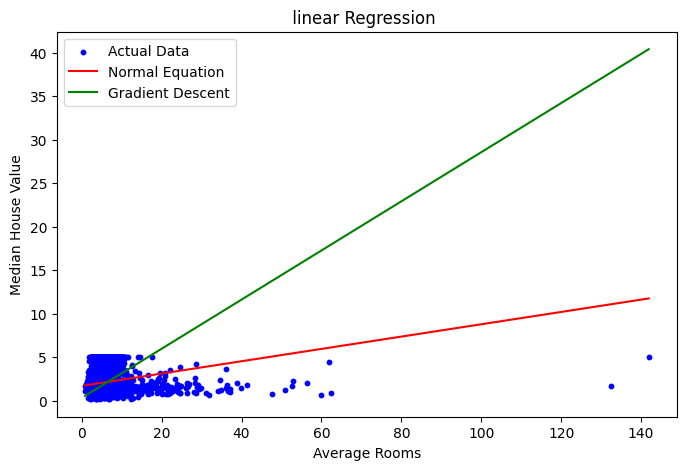

In [87]:
import numpy as np
sort_index=np.argsort(X.flatten())
plt.figure(figsize=(8,5))
plt.scatter(X,y,s=10,color='blue',label='Actual Data')
plt.plot(X[sort_index],y_pred_normal[sort_index],color='red',label='Normal Equation')
plt.plot(X[sort_index],y_pred_gd[sort_index],color='green',label='Gradient Descent')
plt.xlabel("Average Rooms")
plt.ylabel("Median House Value")
plt.title(" linear Regression  ")
plt.legend()
plt.show()

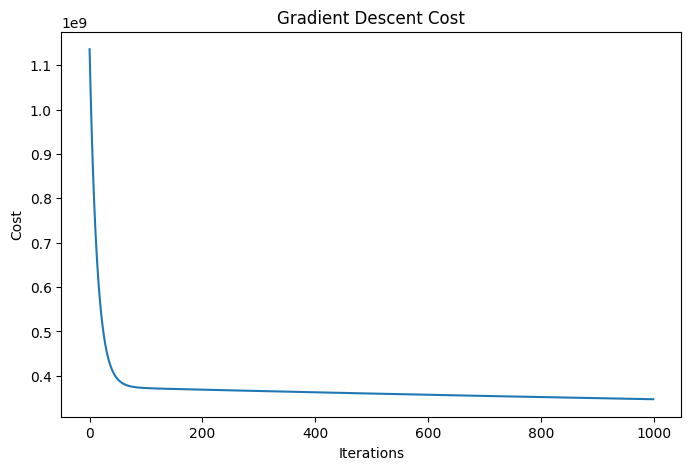

In [88]:
plt.figure(figsize=(8,5))
plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Gradient Descent Cost")
plt.show()